In [ ]:
!pip install xgboost lightgbm catboost imbalanced-learn tensorflow


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Deep learning for temporal modeling
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Attention

# Ensemble
from sklearn.ensemble import VotingClassifier

# Misc
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load dataset
df = pd.read_csv('pcos_flare_synthetic_dataset.csv')

# Preview
print(df.head())
print(df['flare_label'].value_counts(normalize=True))

# Check missing values
print(df.isnull().sum())


    user_id  age        date  acne_severity  hirsutism_severity  \
0  USER_039   41  2024-03-01            0.0                 2.5   
1  USER_029   19  2024-06-19            5.6                 3.3   
2  USER_015   43  2024-04-13            6.2                 4.0   
3  USER_043   28  2024-02-11            1.3                 6.2   
4  USER_008   26  2024-01-25            3.1                 7.5   

   mood_severity  energy_severity  cravings_severity  cycle_day  \
0            8.1              6.9                5.5         25   
1            6.7              2.2                4.1         27   
2            3.9              2.2                9.4         27   
3            4.5              2.6                2.1         12   
4            1.5              6.8                0.8         23   

  flow_intensity  ... sleep_duration stress_score  stressor_notes food_GI  \
0          heavy  ...            7.1         19.8         studies    55.6   
1           none  ...            7.0    

In [ ]:
# Separate features and target
target = 'flare_label'
X = df.drop(columns=[target, 'user_id', 'date'])
y = df[target]

# Identify categorical and numerical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()  # e.g. flow_intensity, pain_level, ovulation_signs, stressor_notes
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

# Transform features
X_processed = preprocessor.fit_transform(X)


In [ ]:
# Apply SMOTE on training data only---------- this is so we can have equal class
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_res)}")


Before SMOTE: [1066  134]
After SMOTE: [1066 1066]


Used RandomizedSearchCV for XGBoost, GridSearchCV for LightGBM, and Bayesian optimization for CatBoost. Parameters like learning rate, tree depth, and number of estimators were tuned to maximize F1-score.

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_dist_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

random_search_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist_xgb, n_iter=10, cv=3, scoring='f1', n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train_res, y_train_res)

print("XGBoost best parameters:", random_search_xgb.best_params_)
best_xgb_model = random_search_xgb.best_estimator_


XGBoost best parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [ ]:
from sklearn.model_selection import GridSearchCV

lgbm = LGBMClassifier(random_state=42)

param_grid_lgbm = {
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

grid_search_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=3, scoring='f1', n_jobs=-1)
grid_search_lgbm.fit(X_train_res, y_train_res)

print("LightGBM best parameters:", grid_search_lgbm.best_params_)
best_lgbm_model = grid_search_lgbm.best_estimator_


[LightGBM] [Info] Number of positive: 1066, number of negative: 1066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001606 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6093
[LightGBM] [Info] Number of data points in the train set: 2132, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.7}


In [ ]:
!pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from catboost import CatBoostClassifier

cat = CatBoostClassifier(random_state=42, verbose=0)

param_space_cat = {
    'iterations': (100, 500),
    'depth': (4, 10),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'l2_leaf_reg': (1, 10)
}

opt_cat = BayesSearchCV(cat, param_space_cat, cv=3, scoring='f1', n_jobs=-1, n_iter=25, random_state=42)
opt_cat.fit(X_train_res, y_train_res)

print("CatBoost best parameters:", opt_cat.best_params_)
best_cat_model = opt_cat.best_estimator_


CatBoost best parameters: OrderedDict({'depth': 4, 'iterations': 238, 'l2_leaf_reg': 1, 'learning_rate': 0.02787427956130534})


Stratified k-fold cross-validation was applied, focusing on F1-score to balance precision and recall, crucial for sensitive health predictions.



In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'XGBoost': XGBClassifier(**random_search_xgb.best_params_, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

for name, model in models.items():
    f1_scores = []
    for train_idx, val_idx in skf.split(X_train_res, y_train_res):
        X_tr, X_val = X_train_res[train_idx], X_train_res[val_idx]
        y_tr, y_val = y_train_res[train_idx], y_train_res[val_idx]

        if name == 'CatBoost':
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=30)
        else:
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)
        f1_scores.append(score)

    print(f"{name} average F1 score (CV): {np.mean(f1_scores):.4f}")

XGBoost average F1 score (CV): 0.9972
[LightGBM] [Info] Number of positive: 853, number of negative: 852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5766
[LightGBM] [Info] Number of data points in the train set: 1705, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500293 -> initscore=0.001173
[LightGBM] [Info] Start training from score 0.001173
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 852, number of negative: 853
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you

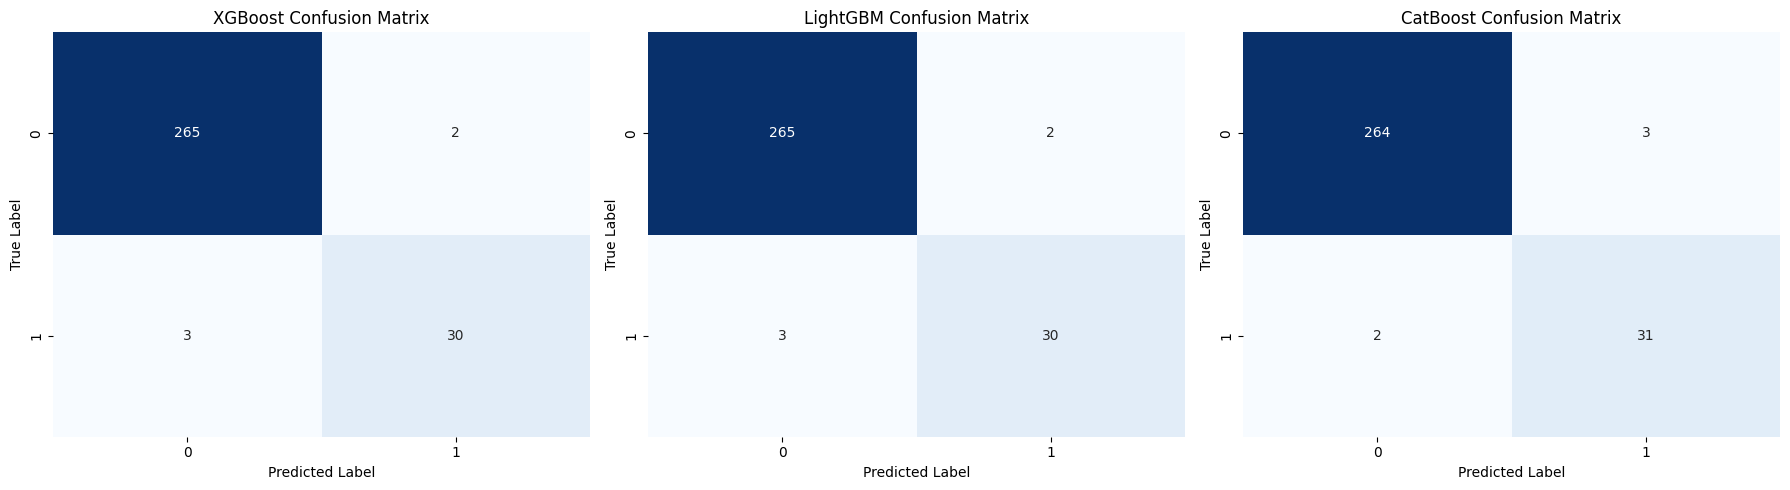

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_preds = {
    'XGBoost': best_xgb_model.predict(X_test),
    'LightGBM': best_lgbm_model.predict(X_test),
    'CatBoost': best_cat_model.predict(X_test)
}

plt.figure(figsize=(18, 5))

for i, (model_name, y_pred) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()


lstm model hybrid

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('pcos_flare_synthetic_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['user_id', 'date'])

# ----- Static Features ---------
static_features = ['age']  # Expand if more static info (BMI, smoking, alcohol) is available

# ----- Temporal Features -------
temporal_features = [
    'acne_severity', 'hirsutism_severity', 'mood_severity', 'energy_severity', 'cravings_severity',
    'cycle_day', 'flow_intensity', 'pain_level', 'ovulation_signs',
    'sleep_quality_score', 'sleep_duration', 'stress_score', 'food_GI', 'food_GL',
    'fasting_glucose', 'weight', 'cycle_length', 'hrv'
]
categorical_temporal = ['flow_intensity', 'pain_level', 'ovulation_signs']

# Encode categorical temporal features
for col in categorical_temporal:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Fill missing values within each user time series
df = df.groupby('user_id').apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))
df.reset_index(drop=True, inplace=True)

# Normalize temporal features
scaler = MinMaxScaler()
df[temporal_features] = scaler.fit_transform(df[temporal_features].values)

# ----- Aggregate and Sequence Creation -----
SEQUENCE_LENGTH = 7

def create_sequences(df, user_col, static_features, temporal_features, target_col, seq_len=SEQUENCE_LENGTH):
    sequences, static_data, labels = [], [], []
    for user in df[user_col].unique():
        user_df = df[df[user_col] == user]
        user_static = user_df.iloc[0][static_features].values  # Static for user
        temp_feats = user_df[temporal_features].values
        targets = user_df[target_col].values
        for i in range(len(user_df) - seq_len):
            sequences.append(temp_feats[i:i+seq_len])
            static_data.append(user_static)
            labels.append(targets[i+seq_len])
    return np.array(static_data), np.array(sequences), np.array(labels)

static_X, seq_X, y = create_sequences(
    df, 'user_id', static_features, temporal_features, 'flare_label', SEQUENCE_LENGTH
)

print(f'Static feature shape: {static_X.shape}')
print(f'Sequence data shape: {seq_X.shape}')
print(f'Labels shape: {y.shape}')

# Split for train/test
X_static_train, X_static_test, X_seq_train, X_seq_test, y_train, y_test = train_test_split(
    static_X, seq_X, y, test_size=0.2, random_state=42, stratify=y
)


Static feature shape: (1150, 1)
Sequence data shape: (1150, 7, 18)
Labels shape: (1150,)


In [ ]:
!pip install tensorflow


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

# Define input shapes
SEQ_LEN = X_seq_train.shape[1]
N_TEMPORAL = X_seq_train.shape[2]
N_STATIC = X_static_train.shape[1]

# Sequential input (time series window)
seq_input = Input(shape=(SEQ_LEN, N_TEMPORAL), name='sequence_input')
x = LSTM(64)(seq_input)
x = Dropout(0.3)(x)

# Static demographic input (e.g., age)
static_input = Input(shape=(N_STATIC,), name='static_input')
s = Dense(8, activation='relu')(static_input)

# Merge static and sequence features
merged = Concatenate()([x, s])
output = Dense(1, activation='sigmoid')(merged)

model = Model(inputs=[seq_input, static_input], outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    [X_seq_train, X_static_train], y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

# Evaluate
loss, accuracy = model.evaluate([X_seq_test, X_static_test], y_test, verbose=0)
print(f"LSTM+Static Test Accuracy: {accuracy:.4f}")


Epoch 1/40
26/26 - 4s - 163ms/step - accuracy: 0.5447 - loss: 0.9602 - val_accuracy: 0.8913 - val_loss: 0.3953
Epoch 2/40
26/26 - 0s - 10ms/step - accuracy: 0.8889 - loss: 0.3964 - val_accuracy: 0.8913 - val_loss: 0.3474
Epoch 3/40
26/26 - 0s - 11ms/step - accuracy: 0.8889 - loss: 0.3562 - val_accuracy: 0.8913 - val_loss: 0.3464
Epoch 4/40
26/26 - 0s - 13ms/step - accuracy: 0.8889 - loss: 0.3576 - val_accuracy: 0.8913 - val_loss: 0.3460
Epoch 5/40
26/26 - 0s - 12ms/step - accuracy: 0.8889 - loss: 0.3523 - val_accuracy: 0.8913 - val_loss: 0.3458
Epoch 6/40
26/26 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.3553 - val_accuracy: 0.8913 - val_loss: 0.3456
Epoch 7/40
26/26 - 0s - 14ms/step - accuracy: 0.8889 - loss: 0.3575 - val_accuracy: 0.8913 - val_loss: 0.3454
Epoch 8/40
26/26 - 1s - 23ms/step - accuracy: 0.8889 - loss: 0.3535 - val_accuracy: 0.8913 - val_loss: 0.3452
Epoch 9/40
26/26 - 1s - 25ms/step - accuracy: 0.8889 - loss: 0.3555 - val_accuracy: 0.8913 - val_loss: 0.3456
Epoch 10/

gru hybrid

In [ ]:
from tensorflow.keras.layers import GRU

# --- GRU sequence model with static features integration ---

# Sequential Input
seq_input = Input(shape=(SEQ_LEN, N_TEMPORAL), name='sequence_input')
x = GRU(64)(seq_input)
x = Dropout(0.3)(x)

# Static Input
static_input = Input(shape=(N_STATIC,), name='static_input')
s = Dense(8, activation='relu')(static_input)

# Merge and Output
merged = Concatenate()([x, s])
output = Dense(1, activation='sigmoid')(merged)

model_gru = Model(inputs=[seq_input, static_input], outputs=output)
model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_gru = model_gru.fit(
    [X_seq_train, X_static_train], y_train,
    epochs=40, batch_size=32, validation_split=0.1,
    callbacks=[early_stop], verbose=2
)

loss, accuracy = model_gru.evaluate([X_seq_test, X_static_test], y_test, verbose=0)
print(f"GRU+Static Test Accuracy: {accuracy:.4f}")


Epoch 1/40
26/26 - 8s - 316ms/step - accuracy: 0.8889 - loss: 0.3603 - val_accuracy: 0.8913 - val_loss: 0.3527
Epoch 2/40
26/26 - 0s - 19ms/step - accuracy: 0.8889 - loss: 0.3599 - val_accuracy: 0.8913 - val_loss: 0.3556
Epoch 3/40
26/26 - 1s - 23ms/step - accuracy: 0.8889 - loss: 0.3522 - val_accuracy: 0.8913 - val_loss: 0.3498
Epoch 4/40
26/26 - 1s - 25ms/step - accuracy: 0.8889 - loss: 0.3536 - val_accuracy: 0.8913 - val_loss: 0.3489
Epoch 5/40
26/26 - 1s - 24ms/step - accuracy: 0.8889 - loss: 0.3535 - val_accuracy: 0.8913 - val_loss: 0.3573
Epoch 6/40
26/26 - 1s - 28ms/step - accuracy: 0.8889 - loss: 0.3471 - val_accuracy: 0.8913 - val_loss: 0.3562
Epoch 7/40
26/26 - 1s - 23ms/step - accuracy: 0.8889 - loss: 0.3491 - val_accuracy: 0.8913 - val_loss: 0.3492
Epoch 8/40
26/26 - 0s - 19ms/step - accuracy: 0.8889 - loss: 0.3481 - val_accuracy: 0.8913 - val_loss: 0.3471
Epoch 9/40
26/26 - 0s - 10ms/step - accuracy: 0.8889 - loss: 0.3463 - val_accuracy: 0.8913 - val_loss: 0.3491
Epoch 10/